# 🧬 ANCOM-BC Differential Abundance Analysis

In [1]:
# iport QIIME2, data wrangling, visualization, and statistical analysis libraries
# QIIME2 is used for artifact handling and Bray–Curtis distance calculation
# pandas/numpy/matplotlib/seaborn support preprocessing and plotting
from qiime2 import Artifact, Metadata
from qiime2.plugins import composition, feature_table
import biom
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import tempfile
import seaborn as sns
import re
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from qiime2.plugins.composition.actions import ancombc
from qiime2.plugins.diversity_lib.methods import bray_curtis

/home/nxwang/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/q2_assembly/_utils.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load Inputs

In [2]:
# load the relative abundance metagenomic feature table from QIIME2 format
# baseline compositional dataset for ANCOM-BC and PERMANOVA
metaG_pergenome_path = '/ddn_scratch/k5zhao/data/metaG-pergenome-clean.qza'
table = Artifact.load(metaG_pergenome_path)
ft_df = table.view(pd.DataFrame)

In [3]:
# standardize sample IDs so feature tables and metadata can be merged consistently
ft_df = ft_df.copy()
ft_df.index = ft_df.index.astype(str).str.split(".", n=1).str[1]
ft_df.index.name = "original_SampleID"

In [4]:
# load cleaned host metadata, estimated absolute abundance table,  and true absolute abundance training table for comparison
# These three tables allow us to compare DA patterns across relative,
# estimated absolute, and measured absolute abundance data
metadata = pd.read_csv('/ddn_scratch/k5zhao/data/metadata_pergenome_clean.tsv', sep='\t', index_col='original_SampleID')
synth_train_df = pd.read_csv('/ddn_scratch/mwdai/capstone/data/synthetic_train.tsv', sep='\t', index_col='original_SampleID')
abs_train_df = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', index_col='original_SampleID')
abs_train_df = abs_train_df.iloc[:, :synth_train_df.shape[1]]

/tmp/ipykernel_61102/3235350869.py:6: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  abs_train_df = pd.read_csv('/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv', index_col='original_SampleID')


In [5]:
# load taxonomy annotations so significant feature IDs can be interpreted biologically at the genus/species level in downstream summaries and figures
tax = pd.read_csv('/ddn_scratch/miter/nph-tables/wolr2-taxonomy.tsv', sep="\t", header=None, names=["feature_id", "taxonomy"], dtype=str)
tax["feature_id"] = tax["feature_id"].str.strip()
tax["taxonomy"]   = tax["taxonomy"].str.strip()
tax = tax.drop_duplicates("feature_id").set_index("feature_id")

## Cleaning Data

In [6]:
# prse QIIME-style taxonomy strings into separate taxonomic ranks
RANKS = ["domain","phylum","class","order","family","genus","species"]
PREFIX = {"domain":"d__", "phylum":"p__", "class":"c__", "order":"o__", "family":"f__", "genus":"g__", "species":"s__"}

def parse_qiime_tax(tax_string: str):
    # returns dict of ranks -> names
    out = {r: np.nan for r in RANKS}
    if pd.isna(tax_string):
        return out
    parts = [p.strip() for p in str(tax_string).split(";")]
    for p in parts:
        for r in RANKS:
            pre = PREFIX[r]
            if p.startswith(pre):
                name = p[len(pre):].strip()
                out[r] = name if name not in ["", "uncultured", "Unassigned"] else np.nan
    return out

rank_df = tax["taxonomy"].apply(parse_qiime_tax).apply(pd.Series)
tax = pd.concat([tax, rank_df], axis=1)

In [7]:
# recode bowel movement type labels into shorter, analysis-friendly categories
metadata['bowel_movement'] = metadata['bowel_movement'].replace({
    '"I tend to have normal formed stool - Type 3 and 4"': 'Type 3/4',
    '"I tend to be constipated (have difficulty passing stool) - Type 1 and 2"': 'Type 1/2',
    '"I tend to have diarrhea (watery stool) - Type 5, 6, and 7"': 'Type 5/6/7'
})

In [8]:
# recode bowel movement quality labels into shorter, analysis-friendly categories
metadata['bowel_movement_quality'] = metadata['bowel_movement_quality'].replace({
    '"I tend to have normal formed stool - Type 3 and 4"': 'Type 3/4',
    '"I tend to be constipated (have difficulty passing stool) - Type 1 and 2"': 'Type 1/2',
    '"I tend to have diarrhea (watery stool) - Type 5, 6, and 7"': 'Type 5/6/7'
})

In [9]:
categorical_vars = ['bowel_movement', 'bowel_movement_quality']
continuous_vars = ['age', 'bmi']
binary_vars = ['sex']
keep_cols = categorical_vars + continuous_vars + binary_vars
metadata_small = metadata[keep_cols].copy()

In [10]:
# Build binned metadata
md = metadata_small.copy()

# Bin age
md["age_bin"] = pd.cut(
    md["age"],
    bins=[18, 30, 40, 50, 60, 70, 100],
    right=False,
    labels=[
        "18-29",
        "30-39",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]
)

#Bin bmi
md["bmi_bin"] = pd.cut(
    md["bmi"],
    bins=[0, 18.5, 25, 30, 40, 1000],
    right=False,
    labels=[
        "under",
        "normal",
        "over",
        "obese",
        "severe_obese"
    ]
)

# Keep only columns used in the model
md = md[
    ["bowel_movement", "bowel_movement_quality", "age_bin", "bmi_bin", "sex"]
].copy()

## Running ANCOM-BC

In [11]:
# # Shared ANCOM-BC parameters
# formula = "bowel_movement + bowel_movement_quality + age_bin + bmi_bin + sex"

# reference_levels = [
#     "sex::female",
#     "bowel_movement::Type 3/4",
#     "bowel_movement_quality::Type 3/4",
#     "age_bin::40-49",
#     "bmi_bin::normal",
# ]

# prv_cut = 0.1

# # run ANCOM-BC on any samples x features table
# def run_ancombc_min(feature_df, md, out_qza):
#     # Convert feature table -> QIIME 2 Artifact
#     biom_table = biom.Table(
#         feature_df.T.values,
#         observation_ids=feature_df.columns.astype(str),  # features
#         sample_ids=feature_df.index.astype(str)          # samples
#     )
#     table_art = Artifact.import_data("FeatureTable[Frequency]", biom_table)

#     # Convert metadata -> qiime2.Metadata
#     with tempfile.NamedTemporaryFile(suffix=".tsv") as f:
#         md.to_csv(
#             f.name,
#             sep="\t",
#             index=True,
#             index_label="#SampleID"
#         )
#         md_q2 = Metadata.load(f.name)

#     # Run ANCOM-BC
#     res = ancombc(
#         table=table_art,
#         metadata=md_q2,
#         formula=formula,
#         p_adj_method="BH",
#         prv_cut=prv_cut,
#         reference_levels=reference_levels,
#     )

#     # Save output
#     res.differentials.save(out_qza)
#     print(f"Saved {out_qza}")
#     return res


# # ----------------------------
# # Run ANCOM-BC for RELATIVE, TRUE ABS (train), SYNTH ABS (train)
# # ----------------------------
# res_rel = run_ancombc_min(ft_df, md, "ancombc_differentials.qza")
# res_abs_train = run_ancombc_min(abs_train_df, md, "abs_train_ancombc_differentials.qza")
# res_synth_train = run_ancombc_min(synth_train_df, md, "synth_train_ancombc_differentials.qza")

In [12]:
# relative
rel_diff = Artifact.load("ancombc_differentials.qza")
os.makedirs("ancombc_export", exist_ok=True)
rel_diff.export_data("ancombc_export")

# absolute
abs_diff = Artifact.load("abs_train_ancombc_differentials.qza")
os.makedirs("ancombc_export_abs", exist_ok=True)
abs_diff.export_data("ancombc_export_abs")

# synthetic
synth_diff = Artifact.load("synth_train_ancombc_differentials.qza")
os.makedirs("ancombc_export_synth", exist_ok=True)
synth_diff.export_data("ancombc_export_synth")

## ANCOM-BC Results

### Relative Abundance

In [13]:
# load ANCOM-BC log-fold changes and adjusted q-values, then count how many taxa are significant for each metadata term
lfc = pd.read_csv("/home/nxwang/ancombc_export/lfc_slice.csv", index_col=0)
q = pd.read_csv("/home/nxwang/ancombc_export/q_val_slice.csv", index_col=0)
sig_counts = (q < 0.05).sum().sort_values(ascending=False)

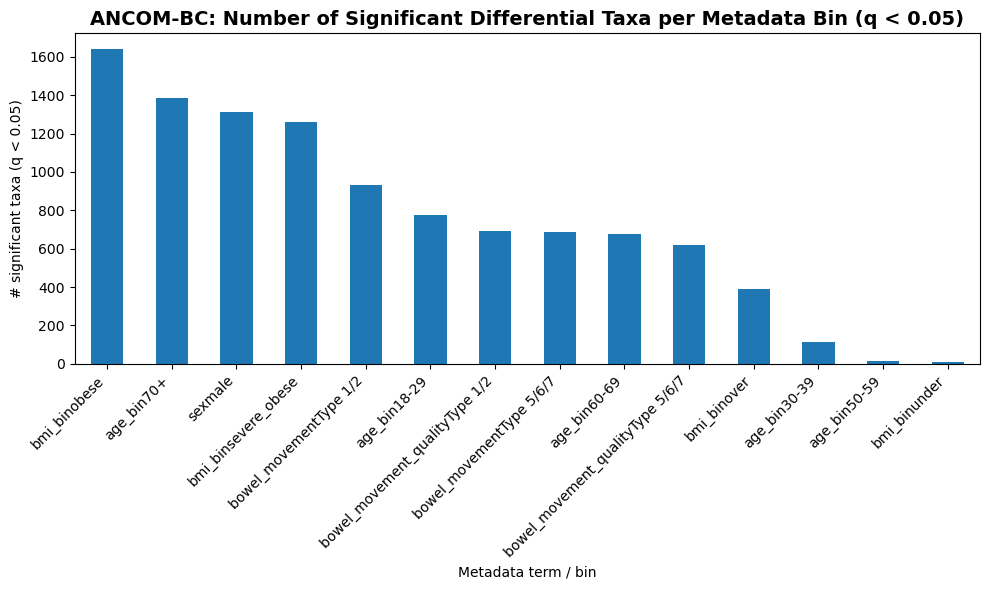

In [14]:
sig_counts = sig_counts.drop("(Intercept)", errors="ignore")

ax = sig_counts.plot(kind="bar", figsize=(10, 6))
ax.set_title("ANCOM-BC: Number of Significant Differential Taxa per Metadata Bin (q < 0.05)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Metadata term / bin")
ax.set_ylabel("# significant taxa (q < 0.05)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./figs/ANCOM-BC/sig_counts.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Mapping Taxanomy to ANCOM-BC results
def join_tax_to_ancom(lfc, q, tax, alpha=0.05):

    lfc_long = lfc.stack(dropna=False).rename("lfc").reset_index()
    lfc_long.columns = ["feature_id", "term", "lfc"]

    q_long = q.stack(dropna=False).rename("q").reset_index()
    q_long.columns = ["feature_id", "term", "q"]

    out = (lfc_long.merge(q_long, on=["feature_id","term"])
                  .merge(tax.reset_index(), on="feature_id", how="left"))

    out["lfc"] = pd.to_numeric(out["lfc"], errors="coerce")
    out["q"]   = pd.to_numeric(out["q"], errors="coerce")

    # drop intercept
    out = out[out["term"] != "(Intercept)"]

    sig = out[(out["q"] < alpha) & out["lfc"].notna()].copy()
    sig["abs_lfc"] = sig["lfc"].abs()

    return out, sig

In [16]:
# join taxonomy annotations to ANCOM-BC outputs so significant hits can be summarized biologically
all_hits, sig_hits = join_tax_to_ancom(lfc, q, tax)

/tmp/ipykernel_61102/1495578020.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  lfc_long = lfc.stack(dropna=False).rename("lfc").reset_index()
/tmp/ipykernel_61102/1495578020.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  q_long = q.stack(dropna=False).rename("q").reset_index()


In [17]:
term_groups = {
    "Age": [
        'age_bin18-29','age_bin30-39','age_bin50-59','age_bin60-69','age_bin70+'
    ],
    "BMI": [
        'bmi_binunder','bmi_binover','bmi_binobese','bmi_binsevere_obese'
    ],
    "Bowel movement type": [
        'bowel_movementType 1/2','bowel_movementType 5/6/7'
    ],
    "Bowel movement quality": [
        'bowel_movement_qualityType 1/2','bowel_movement_qualityType 5/6/7'
    ],
    "Sex": ['sexmale']
}

targets = ['nph_age', 'nph_bmi', 'nph_bowel-movement-type', 'nph_bowel-movement-quality', 'sex']

In [18]:
# group model terms into biological targets (age, BMI, stool, sex)
def map_target(term):
    term = str(term)
    if term.startswith("age_bin"):
        return "nph_age"
    elif term.startswith("bmi_bin"):
        return "nph_bmi"
    elif term.startswith("bowel_movementType"):
        return "nph_bowel-movement-type"
    elif term.startswith("bowel_movement_qualityType"):
        return "nph_bowel-movement-quality"
    elif term.startswith("sex"):
        return "sex"
    else:
        return pd.NA

In [19]:
# build top enriched and depleted taxa tables for each metadata category
def build_topbottom_coef(sig_hits, target, top_n=5, feature_col="species"):
    """
    Returns coef_df (rows=feature_name, cols=terms) for one target,
    using top_n enriched + top_n depleted selection across terms.
    """
    df = sig_hits[sig_hits["target"] == target].copy()
    df["feature_name"] = df[feature_col]

    coef_df = (
        df.pivot_table(
            index=["feature_id", "feature_name"],
            columns="term",
            values="lfc",
            aggfunc="mean"
        )
        .fillna(0)
        .reset_index()
    )

    term_cols = [c for c in coef_df.columns if c not in ["feature_id", "feature_name"]]

    # best enrichment/depletion across columns
    enriched = pd.concat([coef_df[term_cols].max(axis=1), coef_df[["feature_id", "feature_name"]]], axis=1)
    depleted  = pd.concat([coef_df[term_cols].min(axis=1), coef_df[["feature_id", "feature_name"]]], axis=1)
    enriched.columns = [0, "feature_id", "feature_name"]
    depleted.columns = [0, "feature_id", "feature_name"]

    top_depleted = (depleted.sort_values(0).drop_duplicates("feature_name").head(top_n))
    top_enriched = (enriched.sort_values(0, ascending=False).drop_duplicates("feature_name"))
    top_enriched = top_enriched[~top_enriched["feature_name"].isin(top_depleted["feature_name"])].head(top_n)

    selected_ids = top_enriched["feature_id"].tolist() + top_depleted["feature_id"].tolist()

    out = coef_df[coef_df["feature_id"].isin(selected_ids)].copy()
    out = out.set_index("feature_name")[term_cols]

    return out

In [20]:
# x-label cleaner + pretty labels for stool terms
def clean_term_label(t: str) -> str:
    t = str(t)

    # strip leading prefixes
    t = re.sub(r"^age_bin", "", t)
    t = re.sub(r"^bmi_bin", "", t)

    # bowel movement / quality terms -> constipation / diarrhea
    # handles both bowel_movement_qualityType... and bowel_movementType...
    m = re.match(r"^bowel_movement(?:_quality)?Type\s*([0-9/]+)$", t)
    if m:
        code = m.group(1).strip()
        if code == "1/2":
            return "constipation"
        if code in {"5/6/7", "5/6", "6/7"}:
            return "diarrhea"
        return code  # fallback

    # sex
    t = re.sub(r"^sex", "", t)

    # underscores -> spaces
    t = t.replace("_", " ").strip()

    return t

In [21]:
# group model terms for relative abundance significant hits
sig_hits["target"] = sig_hits["term"].apply(map_target)

In [22]:
# Plot multi-panel heatmaps showing ANCOM-BC log-fold changes across metadata bins for the most important taxa
def plot_5panel_heatmaps(sig_hits_df, outpath, suptitle):
    titles = [
    "Age (ref: 40–49)",
    "BMI (ref: normal)",
    "Bowel movement type (ref: normal)",
    "Bowel movement quality (ref: normal)",
    "Sex (ref: female)",
    ]
    
    
    labels = [
    ["18-29", "30-39", "50-59", "60-69", "70+"],      
    ["under", "over", "obese", "severe obese"],   
    ["constipation", "diarrhea"],                       
    ["constipation", "diarrhea"],                        
    ["male"],                                            
    ]
    
    custom_cmap = LinearSegmentedColormap.from_list( "custom-blue-gray-red", ["#7297ec", "#efefef", "#d84e4c"], N=256 )
    
    df_rel_all = []
    for target in targets:
        df_rel = build_topbottom_coef(sig_hits_df, target, top_n=5, feature_col="genus")

        # Optional: reorder BMI bins if present
        if target == "nph_bmi":
            desired_cols = ["bmi_binunder", "bmi_binover", "bmi_binobese", "bmi_binsevere_obese"]
            df_rel = df_rel.loc[:, [c for c in desired_cols if c in df_rel.columns]]

        df_rel_all.append(df_rel)

    # shared color scale
    vmin = min(m.min().min() for m in df_rel_all)
    vmax = max(m.max().max() for m in df_rel_all)

    fig, axes = plt.subplots(1, 5, figsize=(42, 10))
    fig.subplots_adjust(wspace=0.70, right=0.92)

    fig.suptitle(suptitle, fontsize=22, fontweight="bold")

    # shared colorbar axis
    cbar_ax = fig.add_axes([0.935, 0.15, 0.012, 0.7])

    for i, df_rel in enumerate(df_rel_all):
        ax = axes[i]
        show_cbar = (i == len(df_rel_all) - 1)

        sns.heatmap(
            df_rel,
            ax=ax,
            center=0,
            cmap=custom_cmap,
            vmin=vmin, vmax=vmax,
            cbar=show_cbar,
            cbar_ax=cbar_ax if show_cbar else None,
            linewidths=1.0,
            linecolor="white"
        )

        ax.set_title(titles[i], fontsize=16, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("ANCOM-BC" if i == 0 else "", fontsize=18, fontweight="bold")

        xt = [clean_term_label(t.get_text()) for t in ax.get_xticklabels()]
        ax.set_xticklabels(xt, rotation=35, ha="right", fontsize=12)
        ax.tick_params(axis="y", labelsize=11)

    cbar = axes[-1].collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label("Log-fold Change", fontsize=14, labelpad=15)

    plt.savefig(outpath, dpi=500, bbox_inches="tight")
    plt.show()

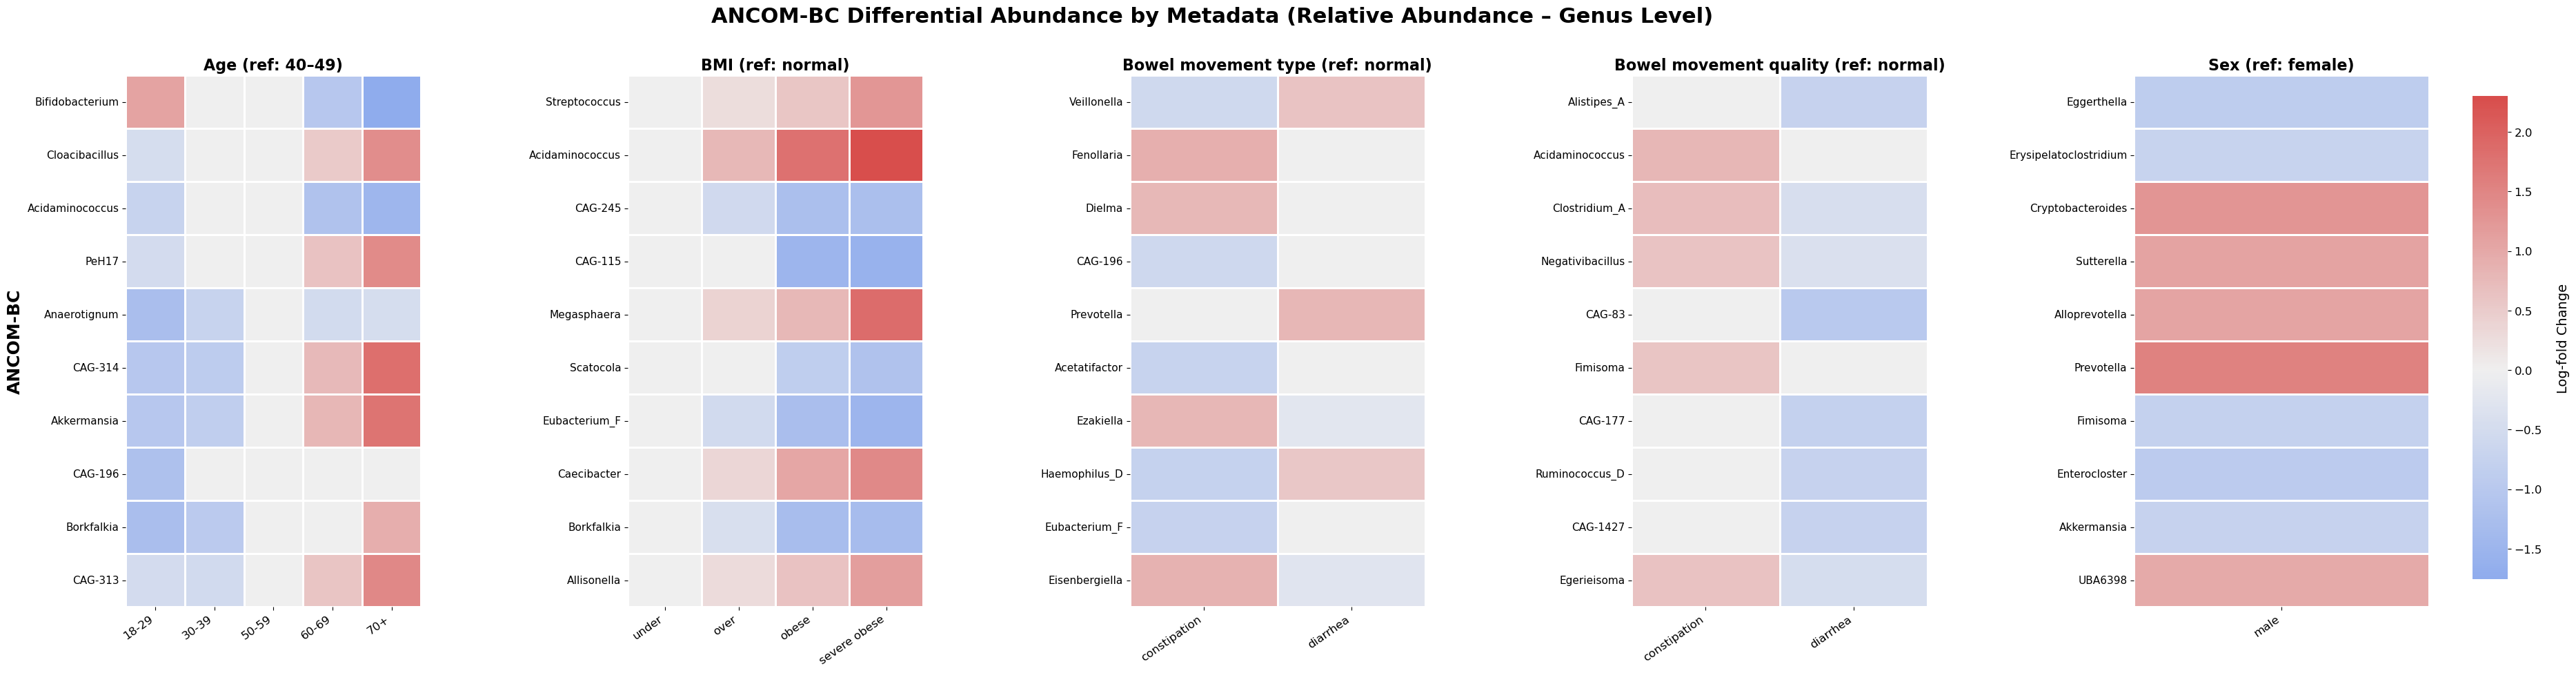

In [23]:
# relative abundance heatmaps
plot_5panel_heatmaps(
    sig_hits,
    outpath="./figs/ANCOM-BC/ancom-bc-genus-5targets_rel_heatmaps.png",
    suptitle="ANCOM-BC Differential Abundance by Metadata (Relative Abundance – Genus Level)"
)

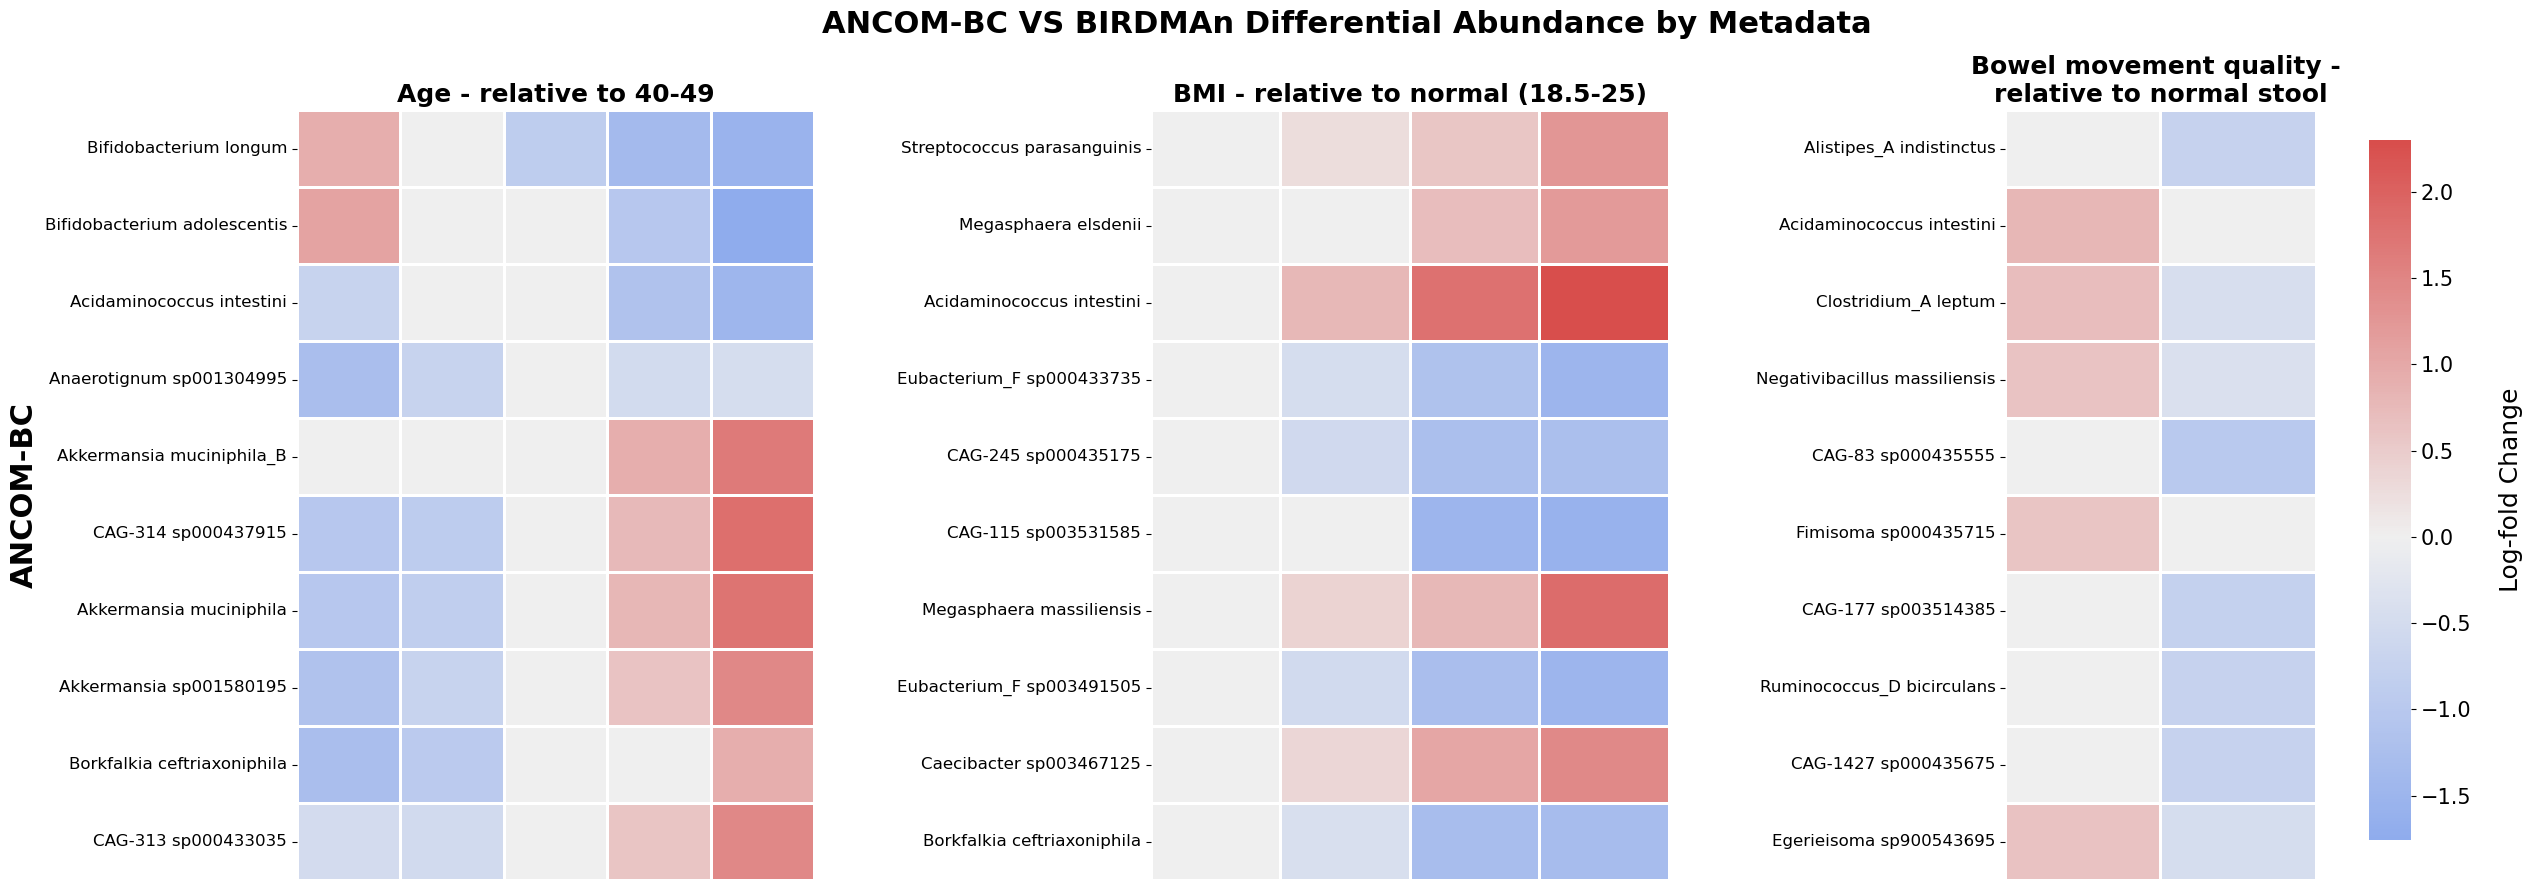

In [24]:
# for poster
targets_poster = ['nph_age', 'nph_bmi', 'nph_bowel-movement-quality']
dfs = []
for target in targets_poster:
    df = build_topbottom_coef(sig_hits, target, top_n=5, feature_col="species")
    
    # Optional: reorder BMI bins if present
    if target == "nph_bmi":
        desired_cols = ["bmi_binunder", "bmi_binover", "bmi_binobese", "bmi_binsevere_obese"]
        df = df.loc[:, [c for c in desired_cols if c in df.columns]]
    
    dfs.append(df)

#heatmap on poster
fig, axes = plt.subplots(1, 3, figsize=(28, 10))
fig.subplots_adjust(wspace=0.65, right=0.92)

fig.suptitle(
    "ANCOM-BC VS BIRDMAn Differential Abundance by Metadata",
    fontsize=22,
    fontweight="bold"
)

titles = [
    "Age - relative to 40-49",
    "BMI - relative to normal (18.5-25)",
    "Bowel movement quality - \nrelative to normal stool"
]

labels = [
    ['18-29', '30-39', '50-59', '60-69', '70+'],
    ['under', 'over', 'obese', 'sever obese'],
    ['constipation', 'diarrhea']
]

custom_cmap = LinearSegmentedColormap.from_list( "custom-blue-gray-red", ["#7297ec", "#efefef", "#d84e4c"], N=256 )

cbar_ax = fig.add_axes([0.865, 0.15, 0.015, 0.7])
vmin = min(df.min().min() for df in dfs)
vmax = max(df.max().max() for df in dfs)

# make only the 3rd heatmap narrower
pos = axes[2].get_position()
new_width = pos.width * 0.6
axes[2].set_position([pos.x0, pos.y0, new_width, pos.height])

for i in range(len(dfs)):
    df = dfs[i]
    ax = axes[i]
    title = titles[i]
    xlabels = labels[i]
    show_cbar = (i == len(dfs) - 1)

    sns.heatmap(
        df,
        ax=ax,
        center=0,
        cmap=custom_cmap,
        vmin=vmin, vmax=vmax,
        cbar=show_cbar,
        cbar_ax=cbar_ax,
        linewidths=1.0,
        linecolor="white"
    )

    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel("ANCOM-BC", fontsize=22, fontweight="bold")

    ax.set_xticklabels([])
    ax.tick_params(bottom=False)

    ax.tick_params(axis="x", rotation=35, labelsize=15)
    ax.tick_params(axis="y", labelsize=12)

    for label in ax.get_xticklabels():
        label.set_fontweight("bold")

axes[1].set_ylabel("")
axes[2].set_ylabel("")

cbar = axes[2].collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label("Log-fold Change", fontsize=18, labelpad=20)

plt.savefig('./figs/ANCOM-BC/ancom-bc-final_heatmaps.png', dpi=500, bbox_inches='tight')
plt.show()

In [25]:
# collapse significant feature-level ANCOM-BC results to the genus level by averaging log-fold changes across all features assigned to the same genus within each metadata term
def genus_lfc_matrix(all_hits):

    df = all_hits.copy()

    # fallback label
    df["genus"] = df["genus"].fillna("Unassigned")

    # aggregate LFC across features → genus
    genus_lfc = (
        df.groupby(["genus","term"])["lfc"]
          .mean()              # mean effect size
          .unstack(fill_value=0)
    )

    return genus_lfc

genus_lfc = genus_lfc_matrix(all_hits)

In [26]:
# plot genus-level ANCOM-BC log-fold change trends across ordered bins for a given metadata group
def plot_group_trends(genus_lfc, group_name, terms, top_n=15):
    sub = genus_lfc[terms].copy()

    score = sub.abs().max(axis=1).sort_values(ascending=False)
    keep = score.head(top_n).index
    sub = sub.loc[keep].fillna(0)

    plt.figure(figsize=(1.0 * len(terms) + 4, max(4, 0.35 * len(keep))))
    for genus in sub.index:
        plt.plot(terms, sub.loc[genus].values, marker="o", linewidth=1)

    plt.axhline(0, linewidth=1)
    plt.title(f"{group_name}: Genus LFC across bins (top {top_n})")
    plt.xlabel("Term / bin")
    plt.ylabel("Log fold change")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    fname = group_name.lower().replace(" ", "_")
    plt.savefig(
        f"./figs/ANCOM-BC/ancombc_{fname}_trends.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

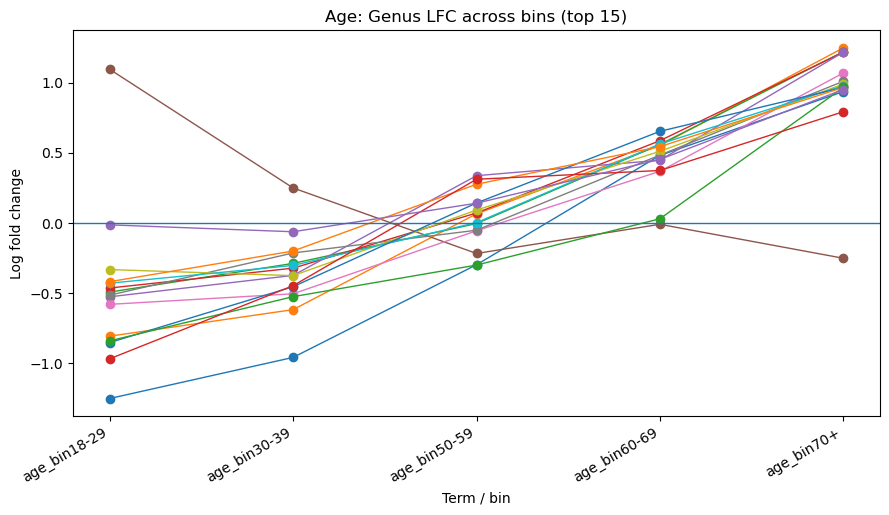

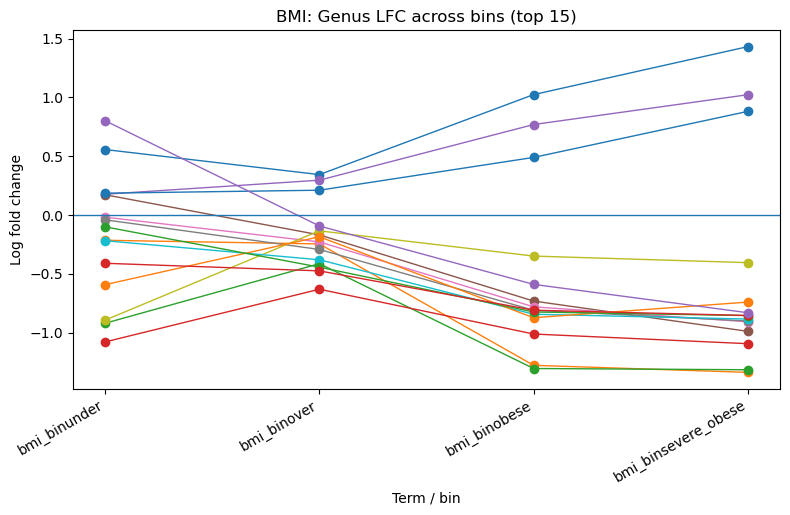

In [27]:
#age
plot_group_trends(genus_lfc, "Age", term_groups["Age"], top_n=15)
#bmi
plot_group_trends(genus_lfc, "BMI", term_groups["BMI"], top_n=15)

### Absolute Abundance

In [28]:
# load ANCOM-BC absolute abundance log-fold changes and adjusted q-values
lfc_abs = pd.read_csv("ancombc_export_abs/lfc_slice.csv", index_col=0)
q_abs = pd.read_csv("ancombc_export_abs/q_val_slice.csv", index_col=0)

# load ANCOM-BC synthetic abundance log-fold changes and adjusted q-values
lfc_synth = pd.read_csv("ancombc_export_synth/lfc_slice.csv", index_col=0)
q_synth = pd.read_csv("ancombc_export_synth/q_val_slice.csv", index_col=0)

In [29]:
# join taxonomy annotations to ANCOM-BC absolute and synthetic abundance outputs so significant hits can be summarized biologically
all_hits_abs, sig_hits_abs = join_tax_to_ancom(lfc_abs, q_abs, tax)
all_hits_synth, sig_hits_synth = join_tax_to_ancom(lfc_synth, q_synth, tax)

/tmp/ipykernel_61102/1495578020.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  lfc_long = lfc.stack(dropna=False).rename("lfc").reset_index()
/tmp/ipykernel_61102/1495578020.py:7: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  q_long = q.stack(dropna=False).rename("q").reset_index()
/tmp/ipykernel_61102/1495578020.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this war

In [30]:
# group model terms for absolute/synthetic abundance significant hits
sig_hits_abs["target"] = sig_hits_abs["term"].apply(map_target)
sig_hits_synth["target"] = sig_hits_synth["term"].apply(map_target)

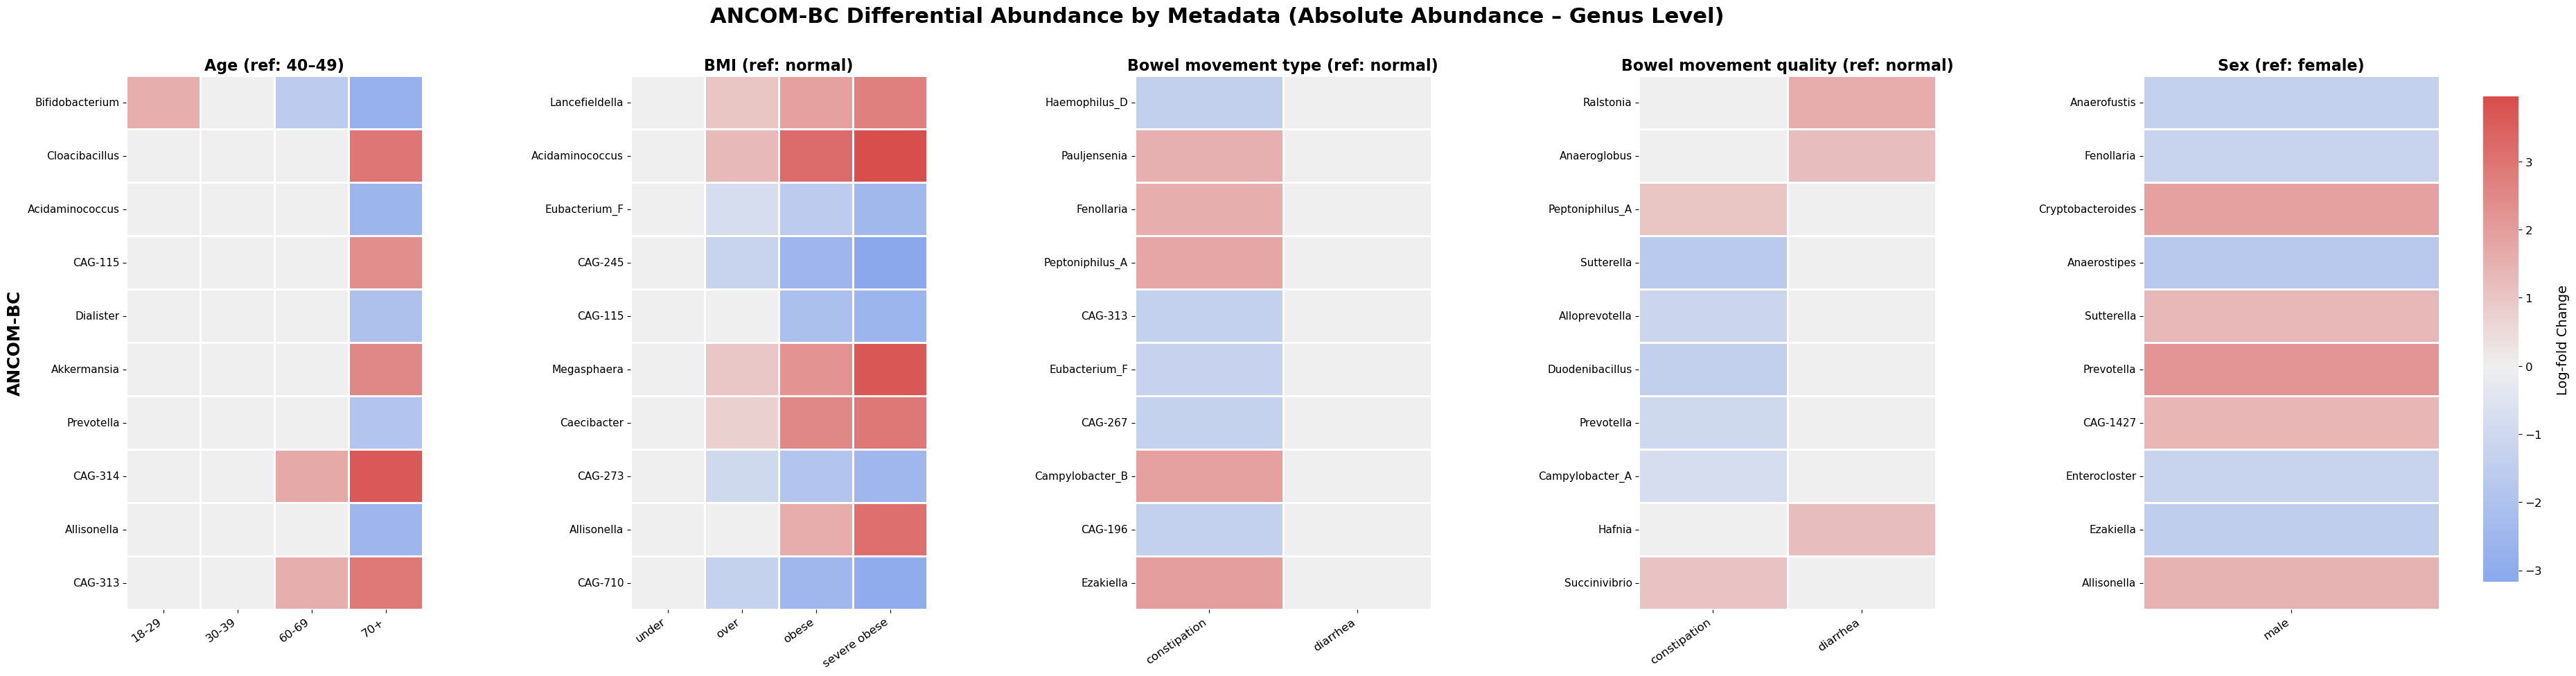

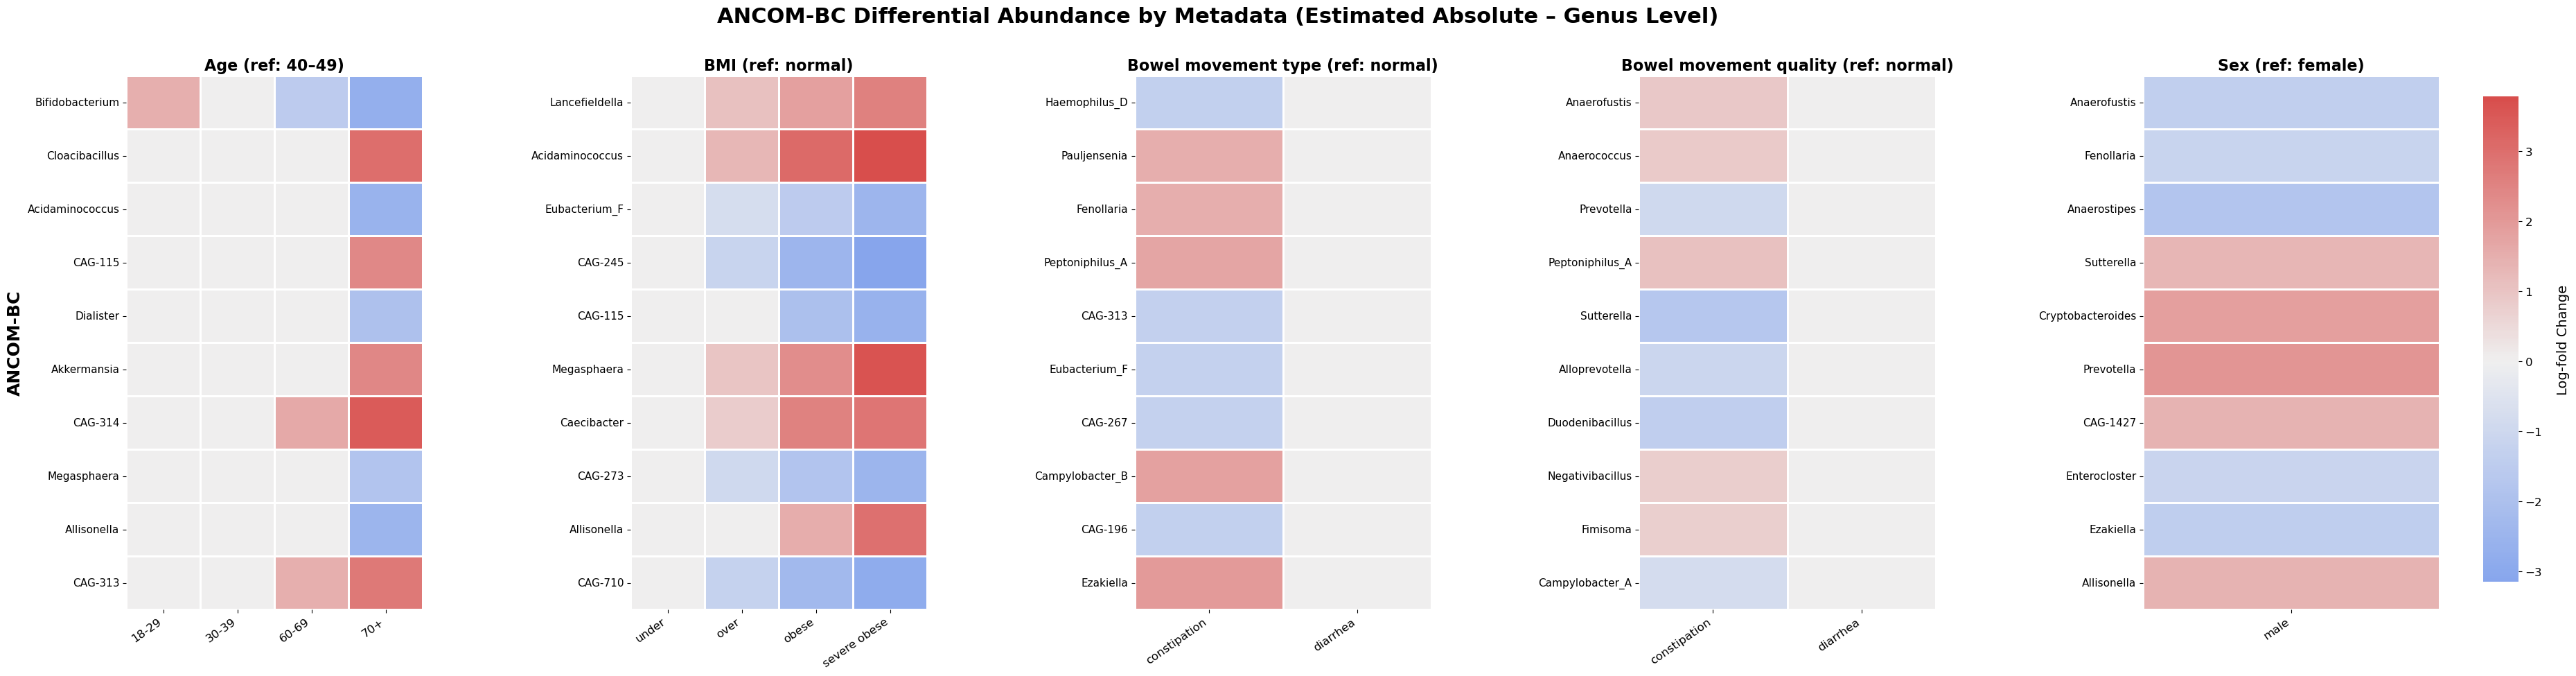

In [31]:
# absolute abundance heatmaps
plot_5panel_heatmaps(
    sig_hits_abs,
    outpath="./figs/ANCOM-BC/ancom-bc-genus-5targets_abs_heatmaps.png",
    suptitle="ANCOM-BC Differential Abundance by Metadata (Absolute Abundance – Genus Level)"
)

# synthetic abundance heatmaps
plot_5panel_heatmaps(
    sig_hits_synth,
    outpath="./figs/ANCOM-BC/ancom-bc-genus-5targets_synth_heatmaps.png",
    suptitle="ANCOM-BC Differential Abundance by Metadata (Estimated Absolute – Genus Level)"
)

## Running PERMANOVA

In [32]:
# # Compute Bray-Curtis distance matrix (QIIME2 DistanceMatrix artifact)
# bray_res = bray_curtis(table=table_art)
# bray_dm_art = bray_res.distance_matrix

# # Save distance matrix to disk as TSV
# dm_fp = "bray_curtis_dm.tsv"
# bray_dm_art.export_data(os.getcwd())  # exports into current directory
# os.replace("distance-matrix.tsv", dm_fp)

In [33]:
# factors = ["bowel_movement", "bowel_movement_quality", "age_bin", "bmi_bin", "sex"]

# md_df = md.copy()

# # Keeping only factors I want
# missing = [c for c in factors if c not in md_df.columns]
# if missing:
#     raise ValueError(f"Missing columns in metadata: {missing}")

# # Read distance matrix IDs (header row/col) to align metadata
# dm = pd.read_csv("bray_curtis_dm.tsv", sep="\t", index_col=0)
# dm_ids = dm.index.astype(str)

# # Subset + align metadata to distance matrix IDs
# md_sub = md_df.loc[md_df.index.astype(str).isin(dm_ids), factors].copy()
# md_sub.index = md_sub.index.astype(str)

# # IMPORTANT: remove samples with any NA in the factors (adonis2 requires complete cases)
# md_sub = md_sub.dropna(axis=0, how="any")

# # Re-filter DM to the remaining metadata IDs (same order)
# keep_ids = md_sub.index.tolist()
# dm = dm.loc[keep_ids, keep_ids]

# # Clean factor levels
# for c in factors:
#     md_sub[c] = md_sub[c].astype(str).str.strip()
#     md_sub[c] = md_sub[c].str.replace("/", "_", regex=False)
#     md_sub[c] = md_sub[c].str.replace(" ", "_", regex=False)
#     md_sub[c] = md_sub[c].astype("category")

# # Save both to disk for R
# md_fp = "permanova_metadata.tsv"
# dm_fp = "bray_curtis_dm.tsv"
# md_sub.to_csv(md_fp, sep="\t")
# dm.to_csv(dm_fp, sep="\t")

In [34]:
# %load_ext rpy2.ipython

In [35]:
# %%R
# library(vegan)

# # Load aligned inputs
# dm <- read.table("bray_curtis_dm.tsv", header=TRUE, row.names=1, sep="\t", check.names=FALSE)
# md <- read.table("permanova_metadata.tsv", header=TRUE, row.names=1, sep="\t", check.names=FALSE)

# # Convert matrix -> dist object
# dm_mat <- as.matrix(dm)
# dm_dist <- as.dist(dm_mat)

# # Make sure columns are factors
# cols <- colnames(md)
# for (c in cols) md[[c]] <- as.factor(md[[c]])

# # Multifactor PERMANOVA (all factors at once)
# set.seed(0)
# res_margin <- adonis2(dm_dist ~ bowel_movement + bowel_movement_quality + age_bin + bmi_bin + sex,
#                       data = md, permutations = 199, by = "margin")

# # Save results
# write.csv(as.data.frame(res_margin), "adonis2_marginal.csv")

## PERMANOVA Results

In [36]:
# Multifactor PERMANOVA (adonis2 by=margin) results plot
# Assumes you already created: adonis2_marginal.csv
# Load PERMANOVA marginal results
perm = pd.read_csv("adonis2_marginal.csv")

term_col = "Unnamed: 0" if "Unnamed: 0" in perm.columns else perm.columns[0]
perm = perm.rename(columns={term_col: "Term"})

perm = perm[~perm["Term"].isin(["Residual", "Total"])]
perm = perm[["Term", "R2", "F", "Pr(>F)"]].copy()

# Compute DA counts per factor from ANCOM-BC q-values
factors = ["bowel_movement", "bowel_movement_quality", "age_bin", "bmi_bin", "sex"]

da_counts = []
for f in factors:
    coef_cols = [c for c in q.columns if c.startswith(f)]
    if len(coef_cols) == 0:
        da_counts.append(0)
        continue
    # count features significant in ANY level of that factor
    sig_any = (q[coef_cols] < 0.05).any(axis=1)
    da_counts.append(int(sig_any.sum()))

da = pd.DataFrame({"Term": factors, "DA_sig_features": da_counts})

summary = perm.merge(da, on="Term", how="left").fillna({"DA_sig_features": 0})

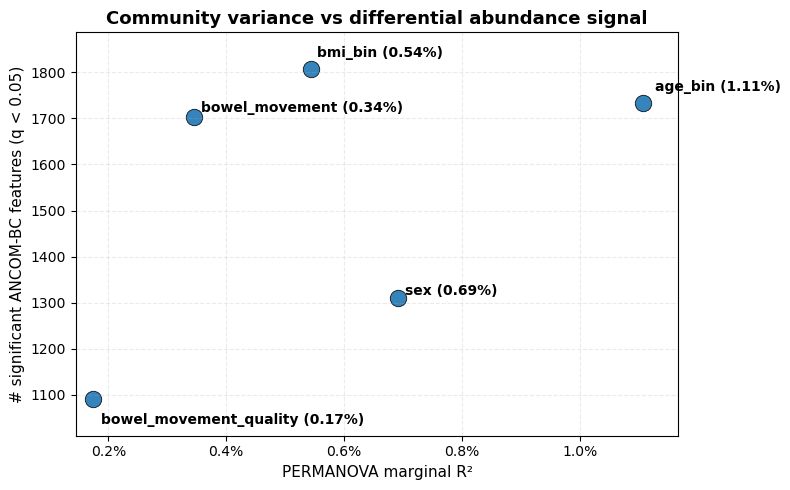

In [37]:
# copy with % labels
df = summary.copy()
df["R2_pct"] = df["R2"] * 100

plt.figure(figsize=(8, 5))

# scatter
plt.scatter(
    df["R2"],
    df["DA_sig_features"],
    s=140,
    alpha=0.9,
    edgecolors="black",
    linewidths=0.6
)

# styling
label_offsets = {
    "age_bin": (0.00020, 35),
    "bmi_bin": (0.00010, 35),
    "sex": (0.00012, 15),
    "bowel_movement": (0.00012, 18),
    "bowel_movement_quality": (0.00012, -45),
}

# Labels
for _, r in df.iterrows():
    term = r["Term"]
    dx, dy = label_offsets.get(term, (0.00012, 12))
    label = f"{term} ({r['R2_pct']:.2f}%)"
    plt.text(
        r["R2"] + dx,
        r["DA_sig_features"] + dy,
        label,
        fontsize=10,
        fontweight="bold",
        ha="left",
        va="center"
    )

plt.xlabel("PERMANOVA marginal R²", fontsize=11)
plt.ylabel("# significant ANCOM-BC features (q < 0.05)", fontsize=11)
plt.title("Community variance vs differential abundance signal", fontsize=13, fontweight="bold")

# X-axis as percent
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))

# Slight padding so labels don't clip
xmin, xmax = df["R2"].min(), df["R2"].max()
ymin, ymax = df["DA_sig_features"].min(), df["DA_sig_features"].max()
plt.xlim(xmin - 0.0003, xmax + 0.0006)
plt.ylim(ymin - 80, ymax + 80)

plt.grid(True, axis="both", linestyle="--", alpha=0.25)
plt.tight_layout()

plt.savefig("./figs/ANCOM-BC/comm_var_vs_da_sig.png", dpi=300, bbox_inches="tight")
plt.show()